# Grad-CAM Analysis for Diabetic Retinopathy Classifier

This notebook provides *publication-quality* visualizations and analysis for a deep learning model
trained to detect Diabetic Retinopathy (DR) from color fundus photographs.

**Goals:**
- Load the trained DR classifier (ResNet-50).
- Run **Grad-CAM** to visualize *where* the model is looking.
- Inspect **correct vs incorrect** predictions.
- Generate figures suitable for:
  - Reports
  - Papers
  - GitHub README
  - Presentations

In [1]:
import os
import sys
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Make src/ importable
sys.path.append("../src")

from model import build_model
from transforms import get_val_transform
from gradcam import GradCAM, overlay_cam_on_image

# If you have load_datasets defined (APTOS / ODIR), we can reuse it:
try:
    from dataset import load_datasets
    HAS_DATASET_LOADER = True
except ImportError:
    HAS_DATASET_LOADER = False
    print("dataset.load_datasets not found – some parts of this notebook will be skipped.")

# Pretty plots
plt.style.use("seaborn-v0_8")

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
DEVICE

device(type='mps')

In [2]:
# -------- CONFIG --------

NUM_CLASSES = 2  # 2 for (DR vs Normal). Change to 5 for severity model.
WEIGHTS_PATH = "/Users/sanjukta/Library/CloudStorage/OneDrive-JohnsHopkins/code/diabetic-retinopathy-resnet/best_model_stage2.pth"  # path from notebooks/ folder
CLASS_NAMES = {0: "DR", 1: "Normal"}       # update for 5-class: 0..4 labels

print("Using device:", DEVICE)
print("Model weights:", WEIGHTS_PATH)
print("Num classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)

Using device: mps
Model weights: /Users/sanjukta/Library/CloudStorage/OneDrive-JohnsHopkins/code/diabetic-retinopathy-resnet/best_model_stage2.pth
Num classes: 2
Class names: {0: 'DR', 1: 'Normal'}


In [9]:
model = build_model(num_classes=NUM_CLASSES, freeze_backbone=False)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

target_layer = model.layer4
cam_extractor = GradCAM(model, target_layer)

val_transform = get_val_transform()

In [10]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def tensor_to_pil(img_tensor):
    img = img_tensor.detach().cpu().numpy().transpose(1,2,0)
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = np.clip(img, 0, 1)
    return Image.fromarray((img * 255).astype(np.uint8))

def show_side_by_side(original, overlay, title_left="Original", title_right="Grad-CAM", suptitle=None):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(original)
    plt.axis("off")
    plt.title(title_left)

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(title_right)

    if suptitle:
        plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

In [11]:
def gradcam_on_image(image_path, class_idx=None, save_path=None):
    img_pil = Image.open(image_path).convert("RGB")

    img_t = val_transform(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_t)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_idx = int(np.argmax(probs))

    if class_idx is None:
        class_idx = pred_idx

    cam_map = cam_extractor.generate(img_t, class_idx=class_idx)
    overlay = overlay_cam_on_image(img_pil, cam_map, alpha=0.4)

    print("Pred:", CLASS_NAMES[pred_idx])
    print("Probs:", {CLASS_NAMES[i]: float(p) for i, p in enumerate(probs)})

    show_side_by_side(img_pil, overlay, suptitle=os.path.basename(image_path))

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        overlay.save(save_path)
        print("Saved:", save_path)

    return img_pil, overlay, pred_idx, probs

Pred: DR
Probs: {'DR': 0.9882504940032959, 'Normal': 0.01174952182918787}


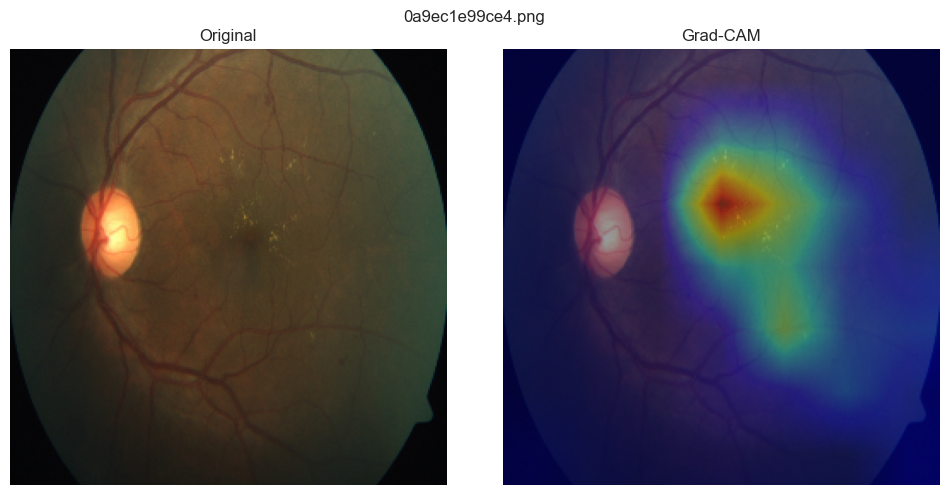

Saved: ../plots/gradcam_example.png


In [18]:
# CHANGE THIS PATH to any test/ODIR/APTOS image you want
SAMPLE_IMAGE = "../data/APTOS_cropped/DR/0a9ec1e99ce4.png"

img_pil, overlay, pred_idx, probs = gradcam_on_image(
    SAMPLE_IMAGE, save_path="../plots/gradcam_example.png"
)